In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("exported_models").resolve()))

from project_models import preparar_diario, weekly_with_gap_regressor, prophet_weekly_with_gap_and_events


/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder,LabelEncoder
import os
import duckdb
from prophet import Prophet
from pathlib import Path
from prophet.diagnostics import cross_validation, performance_metrics
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

In [3]:
DATA_DIR = os.path.expanduser('~/EspecializacionIA/Proyecto_Final/data/tostado')
DB_PATH  = Path(DATA_DIR) / 'ventas.duckdb'

print("CWD:", os.getcwd())
print("DATA_DIR:", DATA_DIR)
print("DB_PATH exists?:", DB_PATH.exists())

# Listar CSVs detectados
csvs = sorted(Path(DATA_DIR).glob("*.xlsx"))
print("XLS count:", len(csvs))
print("Ejemplos:", [p.name for p in csvs[:3]])


CWD: /home/v-tkoller/EspecializacionIA/Proyecto_Final/notebooks
DATA_DIR: /home/v-tkoller/EspecializacionIA/Proyecto_Final/data/tostado
DB_PATH exists?: False
XLS count: 1
Ejemplos: ['ventas_tostado.xlsx']


In [4]:
df_ventas_tostado = pd.read_excel("/home/v-tkoller/EspecializacionIA/Proyecto_Final/data/tostado/ventas_tostado.xlsx")

In [5]:
df_ventas_tostado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   Date              1048575 non-null  datetime64[ns]
 1   ID_Product        1048575 non-null  int64         
 2   ID_Store          1048575 non-null  int64         
 3   Units             1048575 non-null  int64         
 4   Sales             1048575 non-null  float64       
 5   Discount          1048575 non-null  float64       
 6   Product_Name      1048318 non-null  object        
 7   Product_Category  1048460 non-null  object        
 8   Store_Name        1048575 non-null  object        
 9   Store_Chain       1048575 non-null  object        
 10  Store_Country     1048575 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 88.0+ MB


In [6]:
df_ventas_tostado.head()

,Date,ID_Product,ID_Store,Units,Sales,Discount,Product_Name,Product_Category,Store_Name,Store_Chain,Store_Country
0,2024-11-30,100999007,10051,16,0.00,0.00,PAGER 7,PAGERS/OTROS,Aeromendoza,TOSTADO,Argentina
1,2024-08-24,10014080,1008,13,0.00,0.00,CROSSANT JQ + CAFE,PROMOCIONES SALON,Obelisco,TOSTADO,Argentina
2,2024-08-24,10090004,10027,166,0.00,0.00,LECHE DESCREMADA,CAFETERIA EXTRAS,Aeroparque,TOSTADO,Argentina
3,2024-10-24,10020003,10025,16,128192.75,1167.25,CLASICO,TOSTADO DLC CLASICO,Abasto,TOSTADO,Argentina
4,2024-11-29,10020001,1008,3,24550.00,0.00,MIX DE QUESOS,TOSTADO DLC CLASICO,Obelisco,TOSTADO,Argentina


In [7]:
df_ventas_tostado.shape

(1048575, 11)

In [8]:
df_ventas_tostado.describe()

,Date,ID_Product,ID_Store,Units,Sales,Discount
count,1048575,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,2025-01-16 10:10:14.170659584,3.192460e+07,1.508944e+04,7.703035e+00,2.177894e+14,8.387149e+13
min,2023-12-18 00:00:00,1.001000e+03,1.001000e+03,0.000000e+00,-4.421000e+16,-4.931000e+16
25%,2024-07-30 00:00:00,1.007013e+06,1.001100e+04,1.000000e+00,0.000000e+00,0.000000e+00
50%,2025-01-29 00:00:00,1.001801e+07,1.002500e+04,3.000000e+00,5.900000e+03,0.000000e+00
75%,2025-07-17 00:00:00,1.009001e+07,1.004000e+04,8.000000e+00,1.970000e+04,0.000000e+00
max,2025-12-17 00:00:00,5.002000e+08,5.001010e+05,5.940000e+02,8.150940e+16,8.190440e+16
std,NaN,6.202485e+07,5.484361e+04,1.568071e+01,2.707582e+15,1.621222e+15


In [9]:
# Cantidad de duplicados
num_duplicados = df_ventas_tostado.duplicated().sum()
print(f"Total de filas duplicadas: {num_duplicados}")

# Mostrar las primeras filas duplicadas
df_duplicados = df_ventas_tostado[df_ventas_tostado.duplicated()]
print(df_duplicados.head(10))

Total de filas duplicadas: 0
Empty DataFrame
Columns: [Date, ID_Product, ID_Store, Units, Sales, Discount, Product_Name, Product_Category, Store_Name, Store_Chain, Store_Country]
Index: []


In [10]:
# Chequear nulos
print(df_ventas_tostado.isnull().sum())

Date                  0
ID_Product            0
ID_Store              0
Units                 0
Sales                 0
Discount              0
Product_Name        257
Product_Category    115
Store_Name            0
Store_Chain           0
Store_Country         0
dtype: int64


In [11]:
df_ventas_tostado[df_ventas_tostado['Units'].isna()].head()

,Date,ID_Product,ID_Store,Units,Sales,Discount,Product_Name,Product_Category,Store_Name,Store_Chain,Store_Country


In [12]:
df_ventas_tostado=df_ventas_tostado.drop([ 'ID_Product','ID_Store'],axis=1)

In [13]:
df_ventas_tostado.drop(df_ventas_tostado[df_ventas_tostado['Store_Country'] != 'Argentina'].index, inplace=True)

In [14]:
df_ventas_tostado.shape

(1014404, 9)

In [15]:
df_ventas_tostado.groupby("Product_Category")["Units"].sum().reset_index()



,Product_Category,Units
0,0,421135
1,ADP - ADICIONALES,24
2,ADP - ALMACENITOS,42
3,ADP - ANTIPASTOS,23
4,ADP - BEBIDAS,2425
...,...,...
164,WOLOP INTEGR APPS,413
165,WOLOP PROMOS KIOSKO,82
166,WRAPS,59570
167,YOGURT CLUB,89009


In [16]:
df_no_category=df_ventas_tostado[df_ventas_tostado['Product_Category'] == 0] 
df_no_category.head()

,Date,Units,Sales,Discount,Product_Name,Product_Category,Store_Name,Store_Chain,Store_Country
5,2024-11-29,40,175500.45,4499.55,ESPRESSO,0,Aeroparque,TOSTADO,Argentina
14,2024-10-03,24,82258.00,0.00,ESPRESSO,0,Obelisco,TOSTADO,Argentina
20,2024-11-19,6,7758.22,33641.78,HUEVOS,0,Casino,TOSTADO,Argentina
27,2024-11-20,4,19000.00,0.00,HUEVOS,0,Olivos,TOSTADO,Argentina
46,2024-03-20,14,67600.00,5200.00,HUEVOS,0,Ezeiza,TOSTADO,Argentina


In [17]:
df_no_category = (
    df_no_category
    .groupby('Product_Name')
    .size()  # cuenta las filas
    .reset_index(name='Units')
    .sort_values(by='Units', ascending=False)
)

print(df_no_category.head())

  Product_Name  Units
5       HUEVOS  14113
8    MACCHIATO  13375
3     ESPRESSO   7974
7      LAGRIMA   7740
1    CAPUCCINO   6909


In [18]:
df_ventas_tostado = df_ventas_tostado[
    ~(
        df_ventas_tostado["Product_Name"].isin(["#N/A"]) |
        df_ventas_tostado["Product_Category"].isin(["#N/A"]) |
        df_ventas_tostado["Product_Name"].isna() |
        df_ventas_tostado["Product_Category"].isna()
    )
].copy()


In [19]:
categorias_a_eliminar = [
    "PROMOS BANCARIAS",
    "PAGERS/OTROS",
    "OTROS",
    "EVENTO",
    "ADP - CUBIERTOS"
]

df_ventas_tostado.drop(
    df_ventas_tostado[
        df_ventas_tostado["Product_Category"].isin(categorias_a_eliminar)
    ].index,
    inplace=True
)


In [20]:
df_ventas_tostado.shape

(906368, 9)

        Product_Category  Cantidad_Outliers
16             CAFETERIA              15117
18      CAFETERIA EXTRAS              10313
45                 P & P               9153
43         MODIFICADORES               8766
8                BEBIDAS               5315
..                   ...                ...
35             HOT BOWLS                  1
42               MERCADO                  1
32            ESPUMANTES                  1
19  CAMORRA EMPANADAS SA                  1
17         CAFETERIA DEL                  1

[67 rows x 2 columns]


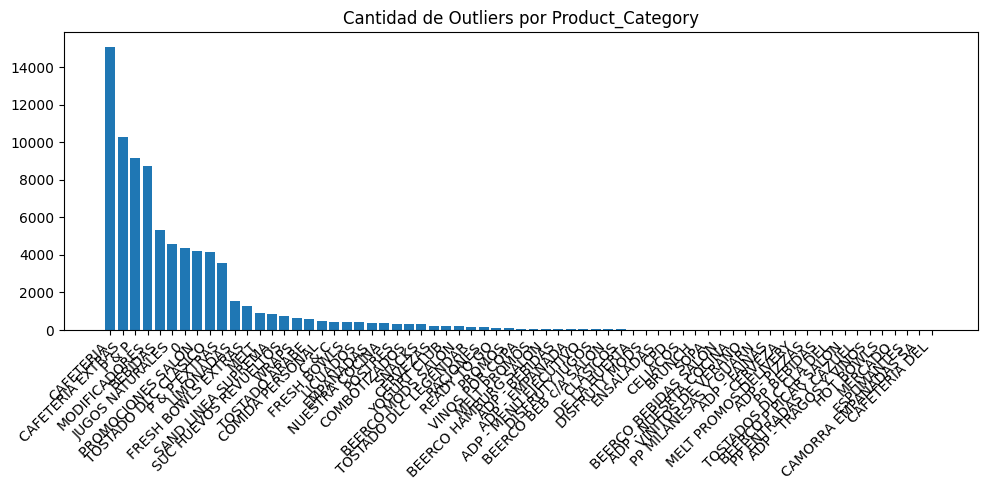

In [22]:
# Columnas numéricas donde buscamos outliers
cols = ['Units']

outliers = pd.DataFrame()

for col in cols:
    Q1 = df_ventas_tostado[col].quantile(0.25)
    Q3 = df_ventas_tostado[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    mask = (df_ventas_tostado[col] < lower) | (df_ventas_tostado[col] > upper)
    outliers = pd.concat([outliers, df_ventas_tostado[mask]], axis=0)

# Eliminar duplicados si el mismo registro es outlier en varias columnas
outliers = outliers.drop_duplicates()

# 🔹 Resumen agrupado por Product_Category
outlier_summary_canal = (
    outliers.groupby('Product_Category')
            .size()
            .reset_index(name='Cantidad_Outliers')
            .sort_values(by='Cantidad_Outliers', ascending=False)
)

print(outlier_summary_canal)


outlier_summary_canal["Product_Category"] = (
    outlier_summary_canal["Product_Category"].astype(str)
)

plt.figure(figsize=(10,5))
plt.bar(
    outlier_summary_canal["Product_Category"],
    outlier_summary_canal["Cantidad_Outliers"]
)
plt.xticks(rotation=45, ha="right")
plt.title("Cantidad de Outliers por Product_Category")
plt.tight_layout()
plt.show()


In [64]:
def map_macro_category(cat, product_name):
    cat = str(cat).upper().strip()
    prod = str(product_name).upper().strip()

    # ---- CAFETERIA ----
    if any(x in cat for x in ["CAFE", "COFFEE", "INFUS", "TEA", "ICED", "GRAOS"]):
        return "CAFETERIA"
    if any(x in prod for x in ["ESPRESSO", "MACCHIATO", "LAGRIMA", "CAFE", "CAPUCCINO", "LATTE"]):
        return "CAFETERIA"

    # ---- BEBIDAS ----
    if any(x in cat for x in [
        "BEBID", "JUGO", "LICUADO", "LIMONADA", "CERVEZA",
        "VINO", "COCKTAIL", "MOCKTAIL", "TRAGO", "ESPUMANTE", "VERM"
    ]):
        return "BEBIDAS"
    if any(x in prod for x in ["JUGO"]):
        return "BEBIDAS"
        

    # ---- COMIDAS ----
    if any(x in cat for x in [
        "TOST", "SAND", "WRAP", "EMPAN", "PIZZA", "BOWL",
        "ENSALAD", "PLATO", "MILAN", "PASTA", "HAMBURG", "FOCACCIA"
    ]):
        return "COMIDAS"
    if any(x in prod for x in ["PAPAS"]):
        return "COMIDAS"

    # ---- DESAYUNOS / BRUNCH ----
    if any(x in cat for x in ["DESAY", "MERIENDA", "BRUNCH", "ALL DAY", "MANHA"]):
        return "DESAYUNOS / BRUNCH"
    if any(x in prod for x in ["HUEVOS", "MEDIALUNA", "CROISSANT", "HUEVO", "TOSTADO"]):
        return "DESAYUNOS / BRUNCH"

    # ---- EXTRAS ----
    if any(x in cat for x in ["EXTRA", "MODIF", "MODS", "ADIC", "GUARN", "CONDIM", "BORD", "MEDID"]):
        return "EXTRAS / MODIFICADORES"

    # ---- POSTRES ----
    if any(x in cat for x in ["POSTRE", "HELADO", "ICE CREAM", "SWEET", "DOLCI", "PASTEL", "SOBREMESA", "YOGURT"]):
        return "POSTRES / DULCES"
    if any(x in prod for x in ["BUDIN", "CAKE", "COOKIE", "ALFAJOR", "DULCE DE LECHE", "CHOCOLATE", "MUFFIN"]):
        return "POSTRES / DULCES"
        

    # ---- PROMOS ----
    if any(x in cat for x in ["PROMO", "COMBO", "EVENT"]):
        return "PROMOS / COMBOS"

    return "OTROS"


In [65]:
df_ventas_tostado["Product_Category_Macro"] = df_ventas_tostado.apply(
    lambda r: map_macro_category(r["Product_Category"], r["Product_Name"]),
    axis=1
)



In [66]:
df_ventas_tostado["Product_Category_Macro"].value_counts()


Product_Category_Macro
CAFETERIA                 238831
COMIDAS                   193858
BEBIDAS                   106321
POSTRES / DULCES           94279
EXTRAS / MODIFICADORES     83123
DESAYUNOS / BRUNCH         71838
OTROS                      70622
PROMOS / COMBOS            47496
Name: count, dtype: int64

In [67]:
df_otros=df_ventas_tostado[df_ventas_tostado['Product_Category_Macro'] == 'OTROS'] 
df_otros.head()

,Date,Units,Sales,Discount,Product_Name,Product_Category,Store_Name,Store_Chain,Store_Country,Product_Category_Macro
24,2024-02-28,2,0.0,0.0,SALSA CHEDDAR PANC VERDEO,BEERCO P PICAR SALON,Ramos Mejia,TOSTADO,Argentina,OTROS
54,2024-03-05,1,1250.0,0.0,CUADRADO LIMON,SNACKS,Mataderos,TOSTADO,Argentina,OTROS
78,2024-11-06,1,7500.0,0.0,FAST CAESAR INT,READY TO GO,Ezeiza,TOSTADO,Argentina,OTROS
90,2024-04-20,24,87900.0,0.0,1/4 KILO,MELT,Olivos,TOSTADO,Argentina,OTROS
96,2024-12-18,8,63200.0,0.0,NATURAL HAM,READY TO GO,Aeropuerto Cordoba,TOSTADO,Argentina,OTROS


In [68]:
df_otros = (
    df_otros
    .groupby('Product_Name')
    .size()  # cuenta las filas
    .reset_index(name='Units')
    .sort_values(by='Units', ascending=False)
)

print(df_otros.head())

                    Product_Name  Units
117                  CHIPA QUESO   7314
186                    ESP CARAM   3315
47      BARRITA CACAO Y AMARANTO   2212
442    ROLL CARNE CON MOZZARELLA   2181
52   BARRITA MATCHA Y ARÃNDANOS   2152
